### **Redes neuronales**
La estructura de la IA parte de redes neuronales.
**Se usan para problemas no lineales**

Usamos tensorFlow para acceder a todo lo de redes neuronales de google
esto ya es deep learning. La forma que se construye la red es con una biblioteca que se llama **Keras**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
## esto me permite usar la red de deep learning de tensorflow (google)

from keras.models import Sequential
### Esto me permite montar una red neuronal que funciona de manera secuencial

from keras.layers import Dense
### Esto me permite crear las capas de la red neuronal


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base=pd.read_csv("/content/drive/MyDrive/Semestre 8/Analitica de negocios/satisfaccion y ventas.csv")
base2=base.drop(columns=["Group"]) # Para borrar la variable que quiero!!! #punto3
base2.isnull().sum()
base3=base2.dropna() #Para borrar los vacios #punto 4
base3.isnull().sum()





Mounted at /content/drive


,0
Customer_Segment,0
Sales_Before,0
Sales_After,0
Customer_Satisfaction_Before,0
Customer_Satisfaction_After,0
Purchase_Made,0


In [ ]:
base3["Customer_Segment"].unique()  ### Muestra todas las categorías distintas que existen en la columna Customer_Segment.
base3['Customer_Segment2']=base3['Customer_Segment'].replace({'High Value':1,
    'Medium Value':2,
    'Low Value':3})
base3

base3["Purchase_Made"].unique()
base3["Purchase_Made2"]=base3["Purchase_Made"].replace({'Yes':1,
    'No':0})
base3.head()

### Redes neuronales solo permite trabajar con valores numericos

/tmp/ipykernel_6314/577390364.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base3['Customer_Segment2']=base3['Customer_Segment'].replace({'High Value':1,
/tmp/ipykernel_6314/577390364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base3['Customer_Segment2']=base3['Customer_Segment'].replace({'High Value':1,
/tmp/ipykernel_6314/577390364.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_object

,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made,Customer_Segment2,Purchase_Made2
1,High Value,246.862114,381.337555,100.000000,100.000000,Yes,1,1
2,High Value,156.978084,179.330464,98.780735,100.000000,No,1,0
3,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes,2,1
6,High Value,191.713918,222.409356,89.967827,85.120975,Yes,1,1
8,High Value,208.308577,248.178830,95.366670,84.790294,Yes,1,1


In [ ]:
base3.columns
y=base3['Purchase_Made2']
x=base3[['Customer_Segment2', 'Sales_Before', 'Sales_After',
       'Customer_Satisfaction_Before', 'Customer_Satisfaction_After']]

x.info()

## Como me doy cuenta que las escalas de las variables son diferentes
## Lo mejor es escalar los datos para que todas las variables tengan la misma magnitud
## Sin perder las caracteristicas originales de distribucion de los datos

scaler=StandardScaler()
xs=scaler.fit_transform(x)
xs
xs=pd.DataFrame(xs,columns=x.columns)
print(xs.head())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
Index: 4010 entries, 1 to 9992
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_Segment2             4010 non-null   int64  
 1   Sales_Before                  4010 non-null   float64
 2   Sales_After                   4010 non-null   float64
 3   Customer_Satisfaction_Before  4010 non-null   float64
 4   Customer_Satisfaction_After   4010 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 188.0 KB
   Customer_Segment2  Sales_Before  Sales_After  Customer_Satisfaction_Before  \
0          -1.241448      0.777212     1.184044                      1.766939   
1          -1.241448     -0.839220    -1.182895                      1.694904   
2          -0.006161     -0.207124    -0.597654                     -1.226447   
3          -1.241448     -0.214547    -0.678135                      1.174234   
4          -1.241448      0.0

In [ ]:
## Vamos a montar un modelo ADALINE
## El modelo va a funcionar con una sola capa y una sola neurona
## La funcion de activacion que va a tener la neurona es lineañ


## 1 definir el modelo, en este caso es un modelo tipo secuential
modelA=Sequential()

## 2 Voy a adicionar una capa y las caracteristicas de la capa
modelA.add(Dense(1,activation="linear",input_dim=5,use_bias=True))
#Cada vez que uso.add adiciono una capa
# Dense es para darle caracteristicas a la capa
## Activation es la funcion con la que quiero que funcione las neuronas de la capa
## input dim es la dimension que quiero usar para la capa ( cuantas variables)

## 3 Voy a darle las caracteristicas de como quiero que funcione el modelo
## En especifico quiero darle caracteristicas de la optimizacion para encontrar los Ws
## Y la forma funcion del error para la optimizacion
modelA.compile(optimizer="adam",loss="mean_squared_error")
#Optimizer es la forma de optimizacion del error para encontrar los W
#Loss es la forma funcional del error que quiero que se optimice
# 4 voy a entrenar el modelo y ademas quiero guardar algunas cosas del entrenamiento
historyA=modelA.fit(xs,y,epochs=300,batch_size=400)
#Epochs es el numero de repeticiones que quiero que haga el modelo
## Batch size es el numero de datos que quiero que tenga en cuenta por repeticion


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8265  
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7665 
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7108 
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6563 
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6044 
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5547 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5059 
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4595 
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4128 
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3682 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3247 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2799 
Epoch 13/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2370 
Epoch 14/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1979 
Epoch 15/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

In [ ]:
#Puedo ver los pesos generales del modelo
wa=modelA.layers[0].get_weights()
wa

[array([[ 0.00865708],
        [ 0.08185125],
        [-0.08807589],
        [ 0.00198952],
        [ 0.0232465 ]], dtype=float32),
 array([0.5032067], dtype=float32)]

**Modelo Madaline**
# Madaline puede tener multiples capas con multiples neuronas




In [ ]:
## Vamos a montar un modelo MADALINE
## El modelo va a funcionar con una sola capa y una sola neurona
## La funcion de activacion que va a tener la neurona es lineañ


## 1 definir el modelo, en este caso es un modelo tipo secuential
modelM=Sequential()

## 2 Voy a adicionar una capa y las caracteristicas de la capa
modelM.add(Dense(5,activation="linear",input_dim=5,use_bias=True))
modelM.add(Dense(1,activation="linear",input_dim=5,use_bias=True))
#Cada vez que uso.add adiciono una capa
# Dense es para darle caracteristicas a la capa
## Activation es la funcion con la que quiero que funcione las neuronas de la capa
## input dim es la dimension que quiero usar para la capa ( cuantas variables)

## 3 Voy a darle las caracteristicas de como quiero que funcione el modelo
## En especifico quiero darle caracteristicas de la optimizacion para encontrar los Ws
## Y la forma funcion del error para la optimizacion
modelM.compile(optimizer="adam",loss="mean_squared_error")
#Optimizer es la forma de optimizacion del error para encontrar los W
#Loss es la forma funcional del error que quiero que se optimice
# 4 voy a entrenar el modelo y ademas quiero guardar algunas cosas del entrenamiento
historyM=modelM.fit(xs,y,epochs=300,batch_size=400)
#Epochs es el numero de repeticiones que quiero que haga el modelo
## Batch size es el numero de datos que quiero que tenga en cuenta por repeticion

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8843  
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7984 
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7278 
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6685 
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6180 
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5737 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5356 
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5020 
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4725 
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4478 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4272 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4085 
Epoch 13/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3929 
Epoch 14/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3794 
Epoch 15/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3667  

In [ ]:
# Como encontrar los pesos generales del modelo
wm0=modelM.layers[0].get_weights()[0]
wm1=modelM.layers[1].get_weights()[0]
wmt=np.dot(wm0,wm1)
wmt

array([[ 0.01214316],
       [-0.03538728],
       [ 0.02204651],
       [-0.00306291],
       [ 0.03143553]], dtype=float32)

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


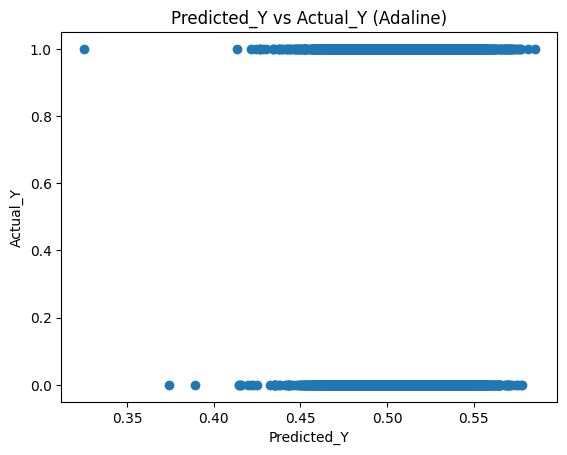

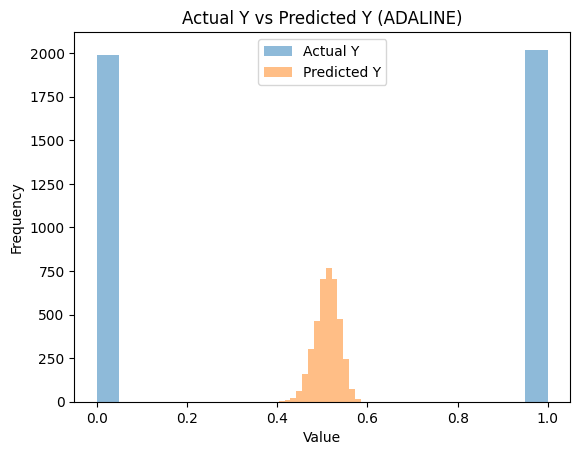

np.float64(-0.03206832215057505)

In [ ]:
## Voy a hacer una prediccion y graficar la prediccion

##Primero voy a hacer una prediccion de y respecto a las x usando el modelo ADALINE
ypredM=modelM.predict(xs)
ypredM=pd.DataFrame(ypredM,columns=["Predicted_Y"])


#Voy a hacer una grafica de dispersion
plt.figure()
plt.scatter(ypredM,y)
plt.xlabel("Predicted_Y")
plt.ylabel("Actual_Y")
plt.title("Predicted_Y vs Actual_Y (Adaline)")
plt.show()

# Grafica de distribuccion de y vs la prediccion
plt.figure()
plt.hist(y, bins=20, alpha=0.5, label='Actual Y')
plt.hist(ypredM, bins=20, alpha=0.5, label='Predicted Y')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Actual Y vs Predicted Y (ADALINE)')
plt.legend()
plt.show()


# Using pandas corr method after converting ypredA to a Series

y.corr(ypredM['Predicted_Y'])

In [ ]:
## Vamos a montar un modelo ADALINE
## El modelo va a funcionar con una sola capa y una sola neurona
## La funcion de activacion que va a tener la neurona es lineañ


## 1 definir el modelo, en este caso es un modelo tipo secuential
modelS=Sequential()

## 2 Voy a adicionar una capa y las caracteristicas de la capa
modelS.add(Dense(1,activation="sigmoid",input_dim=5,use_bias=True))
#Cada vez que uso.add adiciono una capa
# Dense es para darle caracteristicas a la capa
## Activation es la funcion con la que quiero que funcione las neuronas de la capa
## input dim es la dimension que quiero usar para la capa ( cuantas variables)

## 3 Voy a darle las caracteristicas de como quiero que funcione el modelo
## En especifico quiero darle caracteristicas de la optimizacion para encontrar los Ws
## Y la forma funcion del error para la optimizacion
modelS.compile(optimizer="adam",loss="mean_squared_error")
#Optimizer es la forma de optimizacion del error para encontrar los W
#Loss es la forma funcional del error que quiero que se optimice
# 4 voy a entrenar el modelo y ademas quiero guardar algunas cosas del entrenamiento
historyA=modelS.fit(xs,y,epochs=300,batch_size=400)
#Epochs es el numero de repeticiones que quiero que haga el modelo
## Batch size es el numero de datos que quiero que tenga en cuenta por repeticion


Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2640
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2635 
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2631 
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2628 
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2625 
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2622 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2618 
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2615 
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2612 
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2608 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2606 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2603 
Epoch 13/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2600 
Epoch 14/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2598 
Epoch 15/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2595 
Ep

In [ ]:
# Como encontrar los pesos generales del modelo
wm0=modelS.layers[0].get_weights()
wmt

array([[ 0.01214316],
       [-0.03538728],
       [ 0.02204651],
       [-0.00306291],
       [ 0.03143553]], dtype=float32)

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


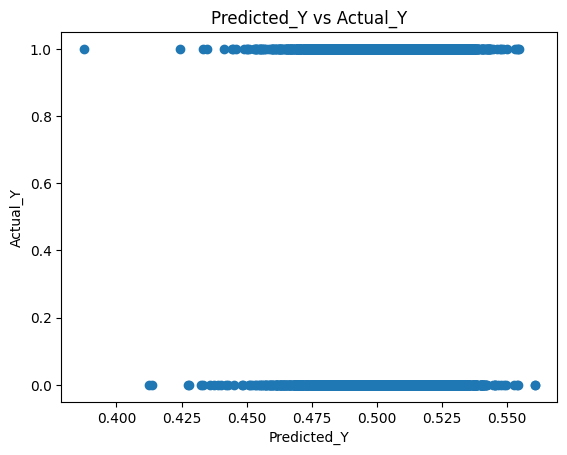

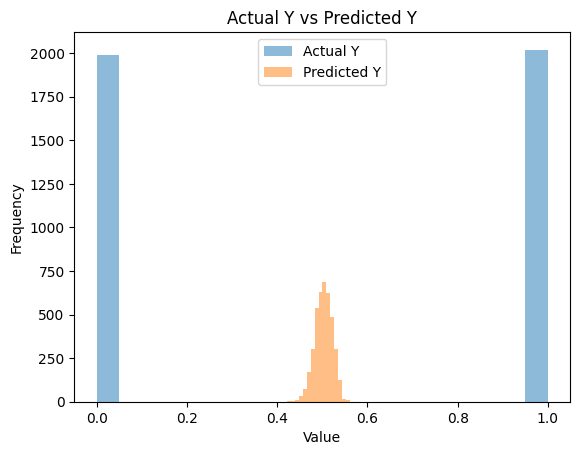

np.float64(-0.013502514602395932)

In [ ]:
## Voy a hacer una prediccion y graficar la prediccion

##Primero voy a hacer una prediccion de y respecto a las x usando el modelo ADALINE
ypredS=modelS.predict(xs)
ypredS=pd.DataFrame(ypredS,columns=["Predicted_Y"])


#Voy a hacer una grafica de dispersion
plt.figure()
plt.scatter(ypredS,y)
plt.xlabel("Predicted_Y")
plt.ylabel("Actual_Y")
plt.title("Predicted_Y vs Actual_Y")
plt.show()

# Grafica de distribuccion de y vs la prediccion
plt.figure()
plt.hist(y, bins=20, alpha=0.5, label='Actual Y')
plt.hist(ypredS, bins=20, alpha=0.5, label='Predicted Y')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Actual Y vs Predicted Y')
plt.legend()
plt.show()


# Using pandas corr method after converting ypredA to a Series

y.corr(ypredS['Predicted_Y'])